In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
sys.path.append('..') 
from quantumSystem.pure_states import pureState

from rich.progress import track

plt.rcParams.update({
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
    })

In [3]:
# Parameters
shot_values = np.linspace(1, 750, num = 100, dtype = int)
n_values = [2, 4, 6, 8, 10]  # example different n values
n_samples = 100

In [4]:
mean_errors = np.zeros(shape = (len(n_values), len(shot_values)))
std_errors = np.zeros(shape = (len(n_values), len(shot_values)))

for w, n in enumerate(n_values):
    diagonals = np.zeros(shape = (n_samples, 2**n))
    one_hot_probabilities = np.zeros(shape = (n_samples, len(shot_values), 2**n))
    norms = np.zeros(shape = (n_samples, len(shot_values)))
    
    for i in track(range(n_samples), description = f"{n} qubits."):
        this_state = pureState(n)
        this_state.haarRandomize()
        this_diag = this_state.density_matrix.diag().numpy()
        diagonals[i] = this_diag.real

        for j, shot in enumerate(shot_values):
            one_hot_ids = np.zeros(shape = (2**n, shot))
            outcome_ids = np.array([this_state.measure()[1] for _ in range(shot)])
            for k, idx in enumerate(outcome_ids):
                one_hot_ids[:, k][idx] = 1 

            one_hot_probabilities[i, j] = one_hot_ids.mean(axis= 1)

        diags_stacked = np.stack([this_diag for _ in range(n_samples)], axis = 1).T
        diff = one_hot_probabilities[i] - diags_stacked
        l2_norm_per_shot = torch.norm(torch.tensor(diff), dim=-1)

        norms[i] = l2_norm_per_shot.numpy()
        
    mean_error = norms.mean(axis = 0)
    std_error = norms.std(axis = 0)
    mean_errors[w] = mean_error
    std_errors[w] = std_error

Output()

KeyboardInterrupt: 

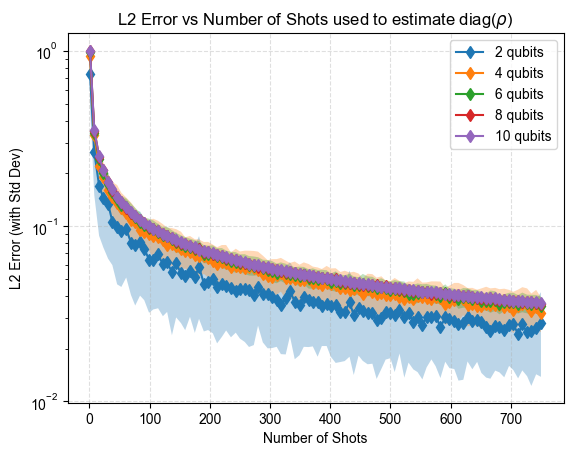

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for i, n in enumerate(n_values):

    plt.plot(shot_values, mean_errors[i], marker='d', label=f'{n} qubits')
    plt.fill_between(
        shot_values,
        (mean_errors[i] - std_errors[i]).numpy(),
        (mean_errors[i] + std_errors[i]).numpy(),
        alpha=0.3
    )


# plt.axhline(0.07, color = 'r', linestyle = "dashed", label = "Error = 0.07")
plt.xlabel('Number of Shots')
plt.ylabel('L2 Error (with Std Dev)')
plt.yscale('log')
plt.title(r'L2 Error vs Number of Shots used to estimate diag($\rho$)')
plt.legend(loc = "best")
plt.grid(True, linestyle='--', alpha=0.4)
plt.savefig(f"shot_sampling.pdf", format="pdf", bbox_inches="tight")
plt.show()

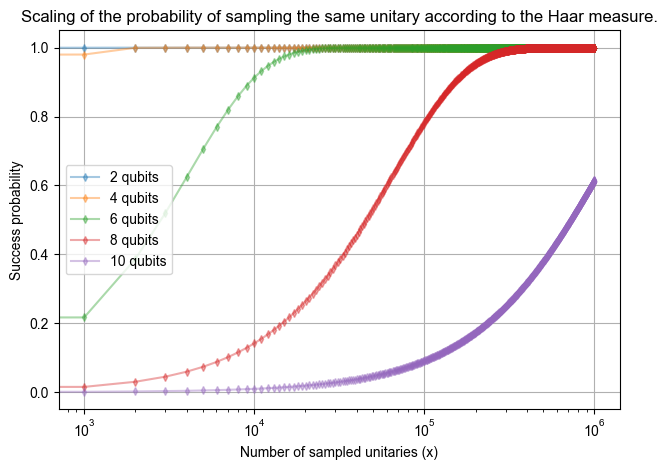

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
epsilon = 0.1  # different k values
x = np.linspace(0, 10e5, 1000)  # number of sampled unitaries

plt.figure()

for k in n_values:
    scale = 1 / (4**k)
    y = 1 - np.exp(-x * scale)
    plt.plot(x, y, label=f"{k} qubits", linestyle='-', marker='d', markersize = 4,  alpha = 0.4)


plt.xlabel("Number of sampled unitaries (x)")
plt.ylabel("Success probability")
plt.xscale('log')
plt.title(r"Scaling of the probability of sampling the same unitary according to the Haar measure.")
plt.legend()
plt.grid(True)
plt.savefig(f"unitary_sampling.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()